In [1]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [125]:
df = yf.download("BTC-USD", start="2015-01-01", end="2023-01-01")["Close"]
df = df.squeeze().dropna()

[*********************100%***********************]  1 of 1 completed


In [126]:
# Moving Averages
fastMA = df.rolling(window=60).mean()
slowMA = df.rolling(window=200).mean()

In [127]:
# Signal — long only
# 1 = fast above slow = uptrend = buy
# 0 = fast below slow = downtrend = stay flat

signal = np.where(fastMA > slowMA,1,0)
signal = np.roll(signal,1) # avoid lookahead bias
signal[0] = 0

In [128]:
# Daily Returns
dailyRet = df.pct_change().fillna(0)

In [129]:
# Strategy Returns
stratRet = signal * dailyRet

In [130]:
# Cumulative returns
cumRet = (1 + stratRet).cumprod() - 1
cumRetBuyHold = (1 + dailyRet).cumprod() - 1

In [131]:
# performance
sharpeRatio = np.sqrt(252) * np.mean(stratRet) / np.std(stratRet)

In [132]:
def calculateMaxDD(cumret):
    cumret = np.array(cumret)
    highwatermark    = np.zeros(cumret.shape)
    drawdown         = np.zeros(cumret.shape)
    drawdownduration = np.zeros(cumret.shape)
    for t in np.arange(1, cumret.shape[0]):
        highwatermark[t] = np.maximum(highwatermark[t-1], cumret[t])
        drawdown[t]      = (1+cumret[t])/(1+highwatermark[t])-1
        if drawdown[t]   == 0:
            drawdownduration[t] = 0
        else:
            drawdownduration[t] = drawdownduration[t-1]+1
    return np.min(drawdown), np.max(drawdownduration)

In [133]:
maxDD, maxDDD = calculateMaxDD(cumRet)

In [134]:
print(f"Sharpe Ratio:          {sharpeRatio:.4f}")
print(f"Max Drawdown:          {maxDD*100:.2f}%")
print(f"Max Drawdown Duration: {maxDDD:.0f} days")
print(f"Total Return:          {cumRet.iloc[-1]*100:.2f}%")
print(f"Buy & Hold Return:     {cumRetBuyHold.iloc[-1]*100:.2f}%")

Sharpe Ratio:          1.0083
Max Drawdown:          -66.49%
Max Drawdown Duration: 1095 days
Total Return:          8028.16%
Buy & Hold Return:     5165.73%


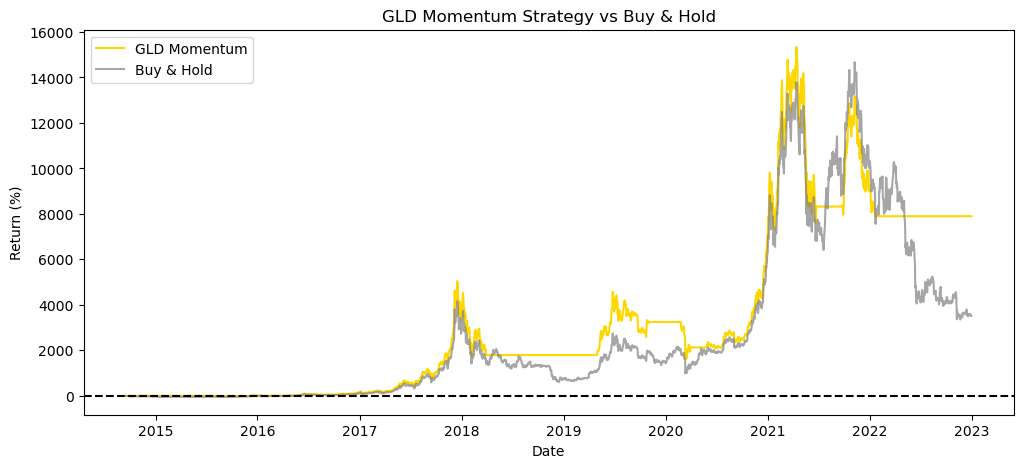

In [124]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(df.index, cumRet*100, label='GLD Momentum', color='gold')
plt.plot(df.index, cumRetBuyHold*100, label='Buy & Hold', color='gray', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title('GLD Momentum Strategy vs Buy & Hold')
plt.ylabel('Return (%)')
plt.xlabel('Date')
plt.legend()
plt.show()

In [136]:
# Kelly calculations
mu = np.mean(stratRet)
variance = np.var(stratRet)
r = 0.04 / 252

In [138]:
f_star      = (mu - r) / variance
f_half      = f_star / 2
f_practical = min(f_star, 0.25)  # capped at 25% — professional standard

In [140]:
print("=" * 40)
print(f"Mean Daily Return (μ):    {mu:.6f}")
print(f"Daily Variance (σ²):      {variance:.6f}")
print(f"Daily Risk Free Rate (r): {r:.6f}")
print("=" * 40)
print(f"Full Kelly:               {f_star*100:.2f}%")
print(f"Half Kelly:               {f_half*100:.2f}%")
print(f"Practical Kelly (capped): {f_practical*100:.2f}%")
print("=" * 40)

Mean Daily Return (μ):    0.002015
Daily Variance (σ²):      0.001006
Daily Risk Free Rate (r): 0.000159
Full Kelly:               184.49%
Half Kelly:               92.25%
Practical Kelly (capped): 25.00%


### Capial growth comparison

In [141]:
capital_fixed = 10000
capital_kelly = 10000
capital_half = 10000

In [142]:
growth_fixed = [capital_fixed]
growth_kelly = [capital_kelly]
growth_half = [capital_half]

In [143]:
for ret in stratRet:
    # fixed - always invest 10% capital
    growth_fixed.append(growth_fixed[-1] * (1 + 0.10 * ret))

    # full kelly
    growth_kelly.append(growth_kelly[-1] * (1 + f_practical * ret))

    # half kelly
    growth_half.append(growth_half[-1] * (1 + f_half * min(ret,0.25) * ret))

In [144]:
growth_fixed = np.array(growth_fixed[1:])
growth_kelly = np.array(growth_kelly[1:])
growth_half  = np.array(growth_half[1:])

In [145]:
# ── Performance Metrics ───────────────────────
def sharpe(returns):
    return np.sqrt(252) * np.mean(returns) / np.std(returns)

def calculateMaxDD(cumret):
    cumret = np.array(cumret)
    highwatermark    = np.zeros(cumret.shape)
    drawdown         = np.zeros(cumret.shape)
    drawdownduration = np.zeros(cumret.shape)
    for t in np.arange(1, len(cumret)):
        highwatermark[t] = np.maximum(highwatermark[t-1], cumret[t])
        drawdown[t]      = (1+cumret[t])/(1+highwatermark[t])-1
        if drawdown[t]   == 0:
            drawdownduration[t] = 0
        else:
            drawdownduration[t] = drawdownduration[t-1]+1
    return np.min(drawdown), np.max(drawdownduration)

In [146]:
cumRet_fixed = (growth_fixed / 10000) - 1
cumRet_kelly = (growth_kelly / 10000) - 1
cumRet_half  = (growth_half  / 10000) - 1

maxDD_fixed, _ = calculateMaxDD(cumRet_fixed)
maxDD_kelly, _ = calculateMaxDD(cumRet_kelly)
maxDD_half,  _ = calculateMaxDD(cumRet_half)

print(f"\n{'Method':<20} {'Total Return':>14} {'Max Drawdown':>14}")
print("-" * 50)
print(f"{'Fixed (10%)':<20} {cumRet_fixed[-1]*100:>13.2f}% {maxDD_fixed*100:>13.2f}%")
print(f"{'Full Kelly (capped)':<20} {cumRet_kelly[-1]*100:>13.2f}% {maxDD_kelly*100:>13.2f}%")
print(f"{'Half Kelly':<20} {cumRet_half[-1]*100:>13.2f}% {maxDD_half*100:>13.2f}%")


Method                 Total Return   Max Drawdown
--------------------------------------------------
Fixed (10%)                  77.52%         -8.70%
Full Kelly (capped)         297.24%        -20.73%
Half Kelly                 1387.97%          0.00%


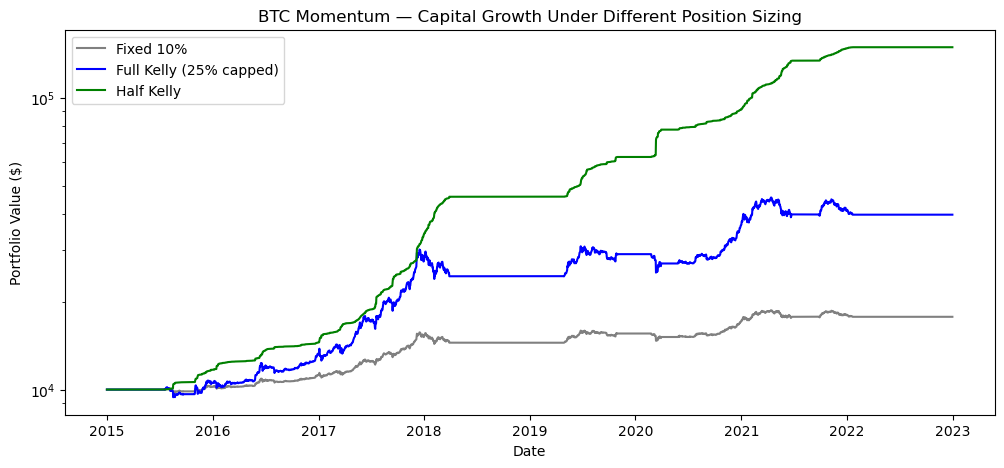

In [148]:
# ── Plot ──────────────────────────────────────
plt.figure(figsize=(12,5))
plt.plot(df.index[:len(growth_fixed)], growth_fixed, label='Fixed 10%', color='gray')
plt.plot(df.index[:len(growth_kelly)], growth_kelly, label=f'Full Kelly ({f_practical*100:.0f}% capped)', color='blue')
plt.plot(df.index[:len(growth_half)],  growth_half,  label='Half Kelly', color='green')
plt.title('BTC Momentum — Capital Growth Under Different Position Sizing')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.legend()
plt.yscale('log')  # log scale so all three are visible
plt.show()